To start off, we look at the data: 
- We see the files it has 
- The shapes of the each image and label
- Plot the first 5 training images

In [14]:
import numpy as np
data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [15]:
train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

print("Train:", train_images.shape, train_labels.shape)
print("Val:  ", val_images.shape, val_labels.shape)
print("Test: ", test_images.shape, test_labels.shape)

print("train_images pixel min/max", train_images.min(), train_images.max())

Train: (97477, 28, 28) (97477,)
Val:   (10832, 28, 28) (10832,)
Test:  (1000, 28, 28) (1000,)
train_images pixel min/max 0 255


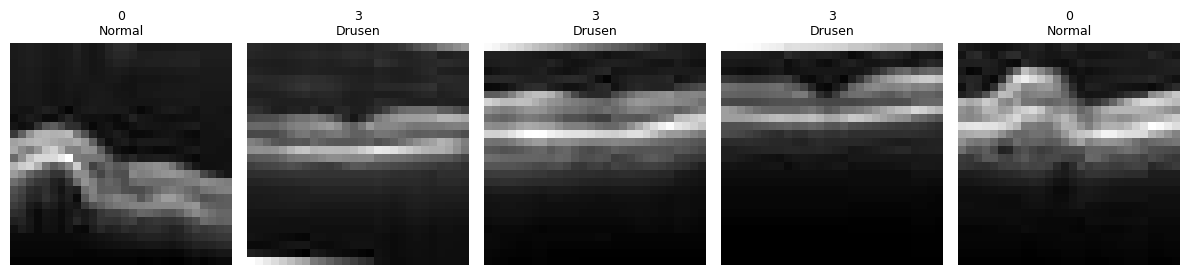

In [13]:
import matplotlib.pyplot as plt
label_names = {
    0: "Normal",
    1: "Choroidal neovascularization",
    2: "Diabetic macular edema",
    3: "Drusen"
}

plt.figure(figsize=(12,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_images[i], cmap="gray")
    label = int(train_labels[i])
    plt.title(f"{label}\n{label_names.get(label, '')}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
val_images.shape
#10k instances
#28 features by 28 features grid

def avg_2x2_pool(array):
    '''Reduced dimensionality of a 3d square array by half'''

    x, y, z = array.shape

    reduced_array = np.zeros((x, int(y/2), int(z/2)))
    for i in range(x):
        for j in range(0, y, 2):
            for k in range(0, z, 2):
                p0 = array[i][j][k]
                p1 = array[i][j][k+1]
                p2 = array[i][j+1][k]
                p3 = array[i][j+1][k+1]

                new_point = (int(p0) + int(p1) + int(p2) +int(p3))/4

                reduced_array[i][int(j/2)][int(k/2)] = new_point

    return reduced_array


In [ ]:
def flatten_data(X):
    new_arr = X.reshape(X.shape[0], -1)
    return new_arr

In [ ]:
def max_2x2_pool(array):
    x, y, z = array.shape

    reduced_array = np.zeros((x, y//2, z//2), dtype=np.float)

    for i in range(x):
        for j in range(0, y, 2):
            for k in range(0, z, 2):
                p0 = float(array[i][j][k])
                p1 = float(array[i][j][k+1])
                p2 = float(array[i][j+1][k])
                p3 = float(array[i][j+1][k+1])

                reduced_array[i][j//2][k//2] = max(p0, p1, p2, p3)

    return reduced_array

In [ ]:
def median_filter_2d(img2d, size=3):
    x, y = img2d.shape
    r = size//2

    arr = np.zeros((x, y), dtype=float)

    for i in range(x):
        for j in range(y):
            window = []
            for ri in range(-r, r + 1):
                for rj in range(-r, r + 1):
                    ii = i + ri
                    jj = j + rj

                    #out of bounds
                    if ii < 0:
                        ii = 0
                    if ii >= x:
                        ii = x - 1
                    if jj < 0:
                        jj = 0
                    if jj >= y:
                        jj = y - 1

                    window.append(float(img2d[ii][[jj]]))
            window.sort()
            arr[i][j] = arr[len(window)//2]
    return arr

In [ ]:
def median_then_avg_pool(array, size=3):
    x, y, z = array.shape
    filtered = np.zeros((x, y, z), dtype=float)

    for i in range(x):
        filtered[i] = median_filter_2d(array[i].astype(np.float32), size=size)

    return avg_2x2_pool(filtered)

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC

flattener = FunctionTransformer(flatten_data, validate=False)
reducer = FunctionTransformer(avg_2x2_pool, validate=False)
scalar = StandardScaler()
svc = SVC()

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

pipe_baseline = Pipeline([
    ("flat", flattener),
    ("scale", scalar),
    ("model", svc)
])

pipe_reduce = Pipeline([
    ("reduce1", reducer),
    ("reduce2", reducer),
    ("flat", flattener),
    ("scale", scalar),
    ("model", svc)
])

pipe_pca = Pipeline([
    ("flat", flattener),
    ("scale", scalar),
    ("pca", PCA(n_components=50)),
    ("model", svc)
])

pipe_both = Pipeline([
    ("reduce1", reducer),
    ("reduce2", reducer),
    ("flat", flattener),
    ("scale", scalar),
    ("pca", PCA(n_components=25)),
    ("model", svc)
])

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import time

def train_eval_model(name, model):
    '''trains and evaluates the model'''
    t1 = time.time()
    model.fit(train_images, train_labels)
    t2 = time.time()

    #get predictions
    pred = model.predict(val_images)

    acc = accuracy_score(val_labels, pred)
    prec = precision_score(val_labels, pred, average="weighted", zero_division=1)
    recall = recall_score(val_labels, pred, average="weighted", zero_division=1)

    print(f"Model: {name}")
    print(f"Training Time: {t2-t1:.3f}")
    print(f'acc: {acc:.4f}')
    print(f'prec:{prec:.4f}')
    print(f'recall:{recall:.4f}\n')

In [ ]:
train_eval_model("Baseline (784 px)", pipe_baseline)
train_eval_model("Reduce (49 px)", pipe_reduce)
train_eval_model("PCA (best 50)", pipe_pca)
train_eval_model("Reduce + PCA (best 25)", pipe_both)